# Laboratorio 6: Transfer Learning y Fine-Tuning

CC3092 Deep Learning y Sistemas Inteligentes, Universidad del Valle de Guatemala

Fabián Morales

En este notebook se comparan tres estrategias para clasificar CIFAR-10: una CNN entrenada desde cero, VGG-16 preentrenada en ImageNet usada como extractor de características y VGG-16 con fine-tuning de sus bloques convolucionales superiores. Para cada estrategia se registra el desempeño y también el costo computacional: parámetros, FLOPs, tiempo, latencia y memoria de GPU.

## 0. Configuración del entorno

Se fijan las semillas para que los resultados sean reproducibles, se detecta el hardware disponible y se crean las carpetas donde se guardan figuras, resultados y checkpoints.

In [1]:
import os, time, json, copy, random, platform, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import VGG16_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from torchinfo import summary
from thop import profile

SEED = 42

def fijar_semilla(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

for carpeta in ["figuras", "resultados", "checkpoints"]:
    os.makedirs(carpeta, exist_ok=True)

def nombre_cpu():
    try:
        salida = subprocess.check_output(
            ["powershell", "-NoProfile", "-Command", "(Get-CimInstance Win32_Processor).Name"], text=True)
        return salida.strip()
    except Exception:
        return platform.processor()

HARDWARE = {
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU",
    "memoria_gpu_gb": round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1) if torch.cuda.is_available() else 0,
    "cpu": nombre_cpu(),
    "sistema": platform.platform(),
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
}
for k, v in HARDWARE.items():
    print(f"{k:15s}: {v}")

gpu            : NVIDIA GeForce RTX 5070 Ti
memoria_gpu_gb : 15.9
cpu            : AMD Ryzen 7 7800X3D 8-Core Processor
sistema        : Windows-11-10.0.26200-SP0
python         : 3.14.4
torch          : 2.14.0+cu130
torchvision    : 0.29.0+cu130


In [2]:
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "lines.linewidth": 2,
})
COLOR_MODELO = {"cnn": "#2a78d6", "fe": "#eb6834", "ft": "#1baf7a"}
NOMBRE_FAMILIA = {"cnn": "CNN desde cero", "fe": "VGG-16 feature extractor", "ft": "VGG-16 fine-tuning"}
COLOR_TRAIN, COLOR_VAL = "#2a78d6", "#eb6834"

## 1. Dataset

CIFAR-10 se descarga con torchvision. El conjunto de entrenamiento oficial se usará para entrenar y validar, y el conjunto de test oficial queda reservado para la evaluación final de los tres modelos.

In [3]:
train_full = datasets.CIFAR10(root="data", train=True, download=True)
test_set = datasets.CIFAR10(root="data", train=False, download=True)

CLASES = train_full.classes
X_train_full = train_full.data
y_train_full = np.array(train_full.targets)
X_test = test_set.data
y_test = np.array(test_set.targets)

print("Entrenamiento:", X_train_full.shape, X_train_full.dtype)
print("Test:         ", X_test.shape)
print("Clases:", CLASES)

Entrenamiento: (50000, 32, 32, 3) uint8
Test:          (10000, 32, 32, 3)
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Exploración y preparación de los datos

### 2.1 Número de observaciones, clases y balance

Observaciones totales: 60000 = 50000 de entrenamiento + 10000 de test
Número de clases: 10


,clase,train,test
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


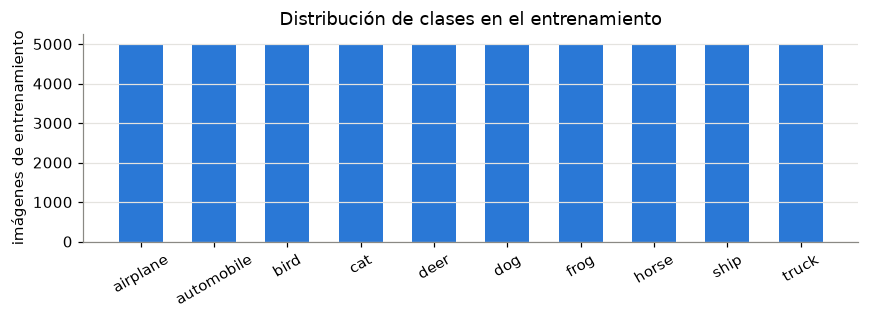

In [4]:
conteo = pd.DataFrame({
    "clase": CLASES,
    "train": np.bincount(y_train_full, minlength=10),
    "test": np.bincount(y_test, minlength=10),
})
print(f"Observaciones totales: {len(y_train_full) + len(y_test)} "
      f"= {len(y_train_full)} de entrenamiento + {len(y_test)} de test")
print(f"Número de clases: {len(CLASES)}")
display(conteo)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(conteo["clase"], conteo["train"], color=COLOR_MODELO["cnn"], width=0.6)
ax.set_ylabel("imágenes de entrenamiento")
ax.set_title("Distribución de clases en el entrenamiento")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.savefig("figuras/distribucion_clases.png"); plt.show()

El dataset tiene 60,000 imágenes: 50,000 de entrenamiento y 10,000 de test, repartidas en 10 clases. Las clases están perfectamente balanceadas, con 5,000 imágenes por clase en entrenamiento y 1,000 por clase en test. Por eso la accuracy es una métrica representativa, aunque igual se reportan precision, recall y F1 macro para ver el comportamiento por clase.

### 2.2 Resolución, canales y estadísticas por canal

In [5]:
print("Resolución:", X_train_full.shape[1:3], "| canales:", X_train_full.shape[3])

X01 = X_train_full.astype(np.float32) / 255.0
media_cifar_full = X01.mean(axis=(0, 1, 2))
desv_cifar_full = X01.std(axis=(0, 1, 2))
del X01

MEDIA_IMAGENET = np.array([0.485, 0.456, 0.406])
DESV_IMAGENET = np.array([0.229, 0.224, 0.225])

estadisticas = pd.DataFrame({
    "canal": ["R", "G", "B"],
    "media CIFAR-10": media_cifar_full.round(4),
    "media ImageNet": MEDIA_IMAGENET,
    "desv CIFAR-10": desv_cifar_full.round(4),
    "desv ImageNet": DESV_IMAGENET,
})
display(estadisticas)

Resolución: (32, 32) | canales: 3


,canal,media CIFAR-10,media ImageNet,desv CIFAR-10,desv ImageNet
0,R,0.4914,0.485,0.2470,0.229
1,G,0.4822,0.456,0.2435,0.224
2,B,0.4465,0.406,0.2616,0.225


Cada imagen es de 32x32 píxeles con 3 canales RGB. Las medias de CIFAR-10 quedan muy cerca de las de ImageNet, con diferencias de apenas unas centésimas, pero las desviaciones estándar de CIFAR-10 son mayores en los tres canales, cerca de 0.25 frente a 0.22-0.23. Esto significa que normalizar CIFAR-10 con las estadísticas de ImageNet produce entradas con media cercana a cero y varianza algo mayor que uno, lo cual es aceptable para VGG-16 porque su primera capa espera exactamente esa escala. Para la CNN desde cero se usan las estadísticas propias de CIFAR-10, calculadas solo sobre el subconjunto de entrenamiento.

### 2.3 Ejemplos por clase

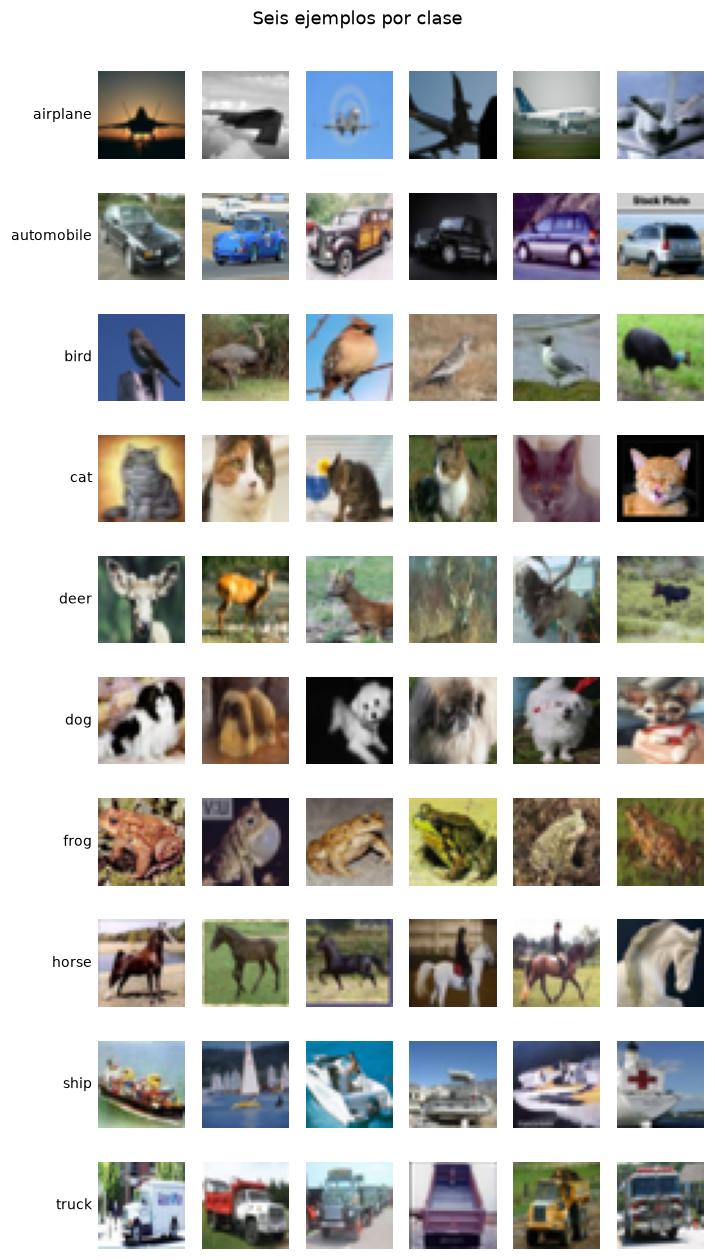

In [6]:
rng = np.random.default_rng(SEED)
n_ej = 6
fig, axes = plt.subplots(10, n_ej, figsize=(n_ej * 1.1, 10 * 1.15))
for c in range(10):
    idx = rng.choice(np.where(y_train_full == c)[0], n_ej, replace=False)
    for j, i in enumerate(idx):
        ax = axes[c, j]
        ax.imshow(X_train_full[i]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values(): s.set_visible(False)
        if j == 0:
            ax.set_ylabel(CLASES[c], rotation=0, ha="right", va="center", fontsize=9)
plt.suptitle("Seis ejemplos por clase", y=1.0)
plt.tight_layout(); plt.savefig("figuras/ejemplos_por_clase.png"); plt.show()

Se espera que los pares más difíciles sean cat y dog, porque ambos son mamíferos peludos de tamaño y pose parecidos y a 32x32 se pierden los detalles de la cara que los distinguen; automobile y truck, que comparten ruedas, ventanas y fondos de carretera; deer y horse, cuadrúpedos marrones sobre fondos verdes; y airplane con ship o bird, porque los tres suelen aparecer sobre un fondo azul uniforme de cielo o agua y el fondo domina la imagen a tan baja resolución.

### 2.4 Pipelines de preprocesamiento

La CNN desde cero trabaja en la resolución nativa de 32x32 y se normaliza con las estadísticas de CIFAR-10. VGG-16 fue entrenada con imágenes de 224x224 normalizadas con la media y desviación de ImageNet, así que sus entradas se redimensionan a 224x224 y se normalizan con esas estadísticas. El preset weights.transforms de torchvision hace Resize a 256 y luego un recorte central de 224, pero ese recorte está pensado para fotografías grandes; en CIFAR-10 cortaría parte del objeto, por lo que aquí se redimensiona directamente a 224x224.

Primero se definen los pipelines de referencia con torchvision.transforms, que documentan exactamente qué se aplica a cada modelo.

In [7]:
idx_todos = np.arange(len(y_train_full))
idx_train, idx_val = train_test_split(idx_todos, test_size=5000, stratify=y_train_full, random_state=SEED)

idx_train_10, _ = train_test_split(idx_train, train_size=0.10, stratify=y_train_full[idx_train], random_state=SEED)

X01_tr = X_train_full[idx_train].astype(np.float32) / 255.0
MEDIA_CIFAR = X01_tr.mean(axis=(0, 1, 2))
DESV_CIFAR = X01_tr.std(axis=(0, 1, 2))
del X01_tr

print(f"train: {len(idx_train)} | val: {len(idx_val)} | train 10 %: {len(idx_train_10)} | test: {len(y_test)}")
print("Imágenes por clase en val:", np.bincount(y_train_full[idx_val]))
print("Imágenes por clase en train 10 %:", np.bincount(y_train_full[idx_train_10]))
print("Media CIFAR train:", MEDIA_CIFAR.round(4), "| desv:", DESV_CIFAR.round(4))

train: 45000 | val: 5000 | train 10 %: 4500 | test: 10000
Imágenes por clase en val: [500 500 500 500 500 500 500 500 500 500]
Imágenes por clase en train 10 %: [450 450 450 450 450 450 450 450 450 450]
Media CIFAR train: [0.4911 0.4821 0.4464] | desv: [0.2469 0.2434 0.2616]


In [8]:
RES_VGG = 224

pipeline_cnn_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_CIFAR.tolist(), DESV_CIFAR.tolist()),
])
pipeline_cnn_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_CIFAR.tolist(), DESV_CIFAR.tolist()),
])
pipeline_vgg_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((RES_VGG, RES_VGG)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET.tolist(), DESV_IMAGENET.tolist()),
])
pipeline_vgg_eval = transforms.Compose([
    transforms.Resize((RES_VGG, RES_VGG)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET.tolist(), DESV_IMAGENET.tolist()),
])
print("Preset oficial de los pesos:", VGG16_Weights.IMAGENET1K_V1.transforms())

pix_32, pix_224 = 32 * 32, 224 * 224
print(f"\nPíxeles por imagen: 32x32 = {pix_32:,} | 224x224 = {pix_224:,} | factor = {pix_224 / pix_32:.0f}x")
print(f"Con 128x128 el factor sería {128 * 128 / pix_32:.0f}x")

Preset oficial de los pesos: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Píxeles por imagen: 32x32 = 1,024 | 224x224 = 50,176 | factor = 49x
Con 128x128 el factor sería 16x


Pasar de 32x32 a 224x224 multiplica el número de píxeles por 49, de 1,024 a 50,176. En una red convolucional el costo de cada capa es proporcional al área del mapa de características, así que el cómputo por imagen, la memoria de activaciones y el tiempo por epoch crecen aproximadamente en ese mismo factor. Esa es la principal razón por la que VGG-16 es mucho más cara que la CNN propia aunque la imagen no contenga información nueva: los píxeles adicionales son interpolaciones de los originales.

Para no depender de un DataLoader en CPU, que en Windows es un cuello de botella al redimensionar 45,000 imágenes por epoch, el dataset completo se sube a la GPU en uint8 y las mismas transformaciones se aplican por lote en la GPU. La celda siguiente verifica que el pipeline en GPU produce el mismo resultado que el pipeline de referencia de torchvision.

In [9]:
X_train_gpu = torch.from_numpy(X_train_full).permute(0, 3, 1, 2).contiguous().to(DEVICE)
y_train_gpu = torch.from_numpy(y_train_full).long().to(DEVICE)
X_test_gpu = torch.from_numpy(X_test).permute(0, 3, 1, 2).contiguous().to(DEVICE)
y_test_gpu = torch.from_numpy(y_test).long().to(DEVICE)

NORM = {
    "cnn": (torch.tensor(MEDIA_CIFAR, device=DEVICE).view(1, 3, 1, 1), torch.tensor(DESV_CIFAR, device=DEVICE).view(1, 3, 1, 1)),
    "vgg": (torch.tensor(MEDIA_IMAGENET, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1),
            torch.tensor(DESV_IMAGENET, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)),
}

def aumentar_lote(x, padding=4):
    B, C, H, W = x.shape
    xp = F.pad(x, (padding,) * 4)
    dy = torch.randint(0, 2 * padding + 1, (B,), device=x.device)
    dx = torch.randint(0, 2 * padding + 1, (B,), device=x.device)
    filas = (dy[:, None] + torch.arange(H, device=x.device))[:, None, :, None]
    cols = (dx[:, None] + torch.arange(W, device=x.device))[:, None, None, :]
    x = xp[torch.arange(B, device=x.device)[:, None, None, None], torch.arange(C, device=x.device)[None, :, None, None], filas, cols]
    voltear = torch.rand(B, device=x.device) < 0.5
    return torch.where(voltear[:, None, None, None], x.flip(3), x)

def preparar_lote(xb, modo, aumentar=False, res=RES_VGG):
    x = xb.float().div_(255.0)
    if aumentar:
        x = aumentar_lote(x)
    if modo == "vgg" and res != 32:
        x = F.interpolate(x, size=(res, res), mode="bilinear", align_corners=False)
    media, desv = NORM[modo]
    return ((x - media) / desv).contiguous(memory_format=torch.channels_last)

from PIL import Image
muestra = [Image.fromarray(X_train_full[i]) for i in range(8)]
ref_cnn = torch.stack([pipeline_cnn_eval(im) for im in muestra])
ref_vgg = torch.stack([pipeline_vgg_eval(im) for im in muestra])
gpu_cnn = preparar_lote(X_train_gpu[:8], "cnn").float().cpu()
gpu_vgg = preparar_lote(X_train_gpu[:8], "vgg").float().cpu()
print("Diferencia máxima CNN:", (ref_cnn - gpu_cnn).abs().max().item())
print("Diferencia media VGG:", (ref_vgg - gpu_vgg).abs().mean().item(),
      "| la pequeña diferencia viene de la interpolación de PIL frente a la de PyTorch")

Diferencia máxima CNN:

 4.76837158203125e-07
Diferencia media VGG: 0.004717126023024321 | la pequeña diferencia viene de la interpolación de PIL frente a la de PyTorch


### 2.5 Data augmentation

Se usan dos transformaciones clásicas para CIFAR-10. RandomCrop de 32 con padding de 4 desplaza el objeto hasta 4 píxeles en cada dirección, lo que enseña a la red que la clase no depende de la posición exacta. RandomHorizontalFlip refleja la imagen con probabilidad 0.5, lo cual es válido porque un gato o un camión reflejado sigue siendo la misma clase. No se usan rotaciones grandes ni volteo vertical porque producen imágenes poco realistas, como barcos de cabeza. En VGG-16 la augmentation se aplica sobre la imagen de 32x32 antes del redimensionamiento, para que el desplazamiento equivalga al mismo contenido.

La augmentation se aplica solo al entrenamiento porque su objetivo es aumentar la variedad de ejemplos que ve el modelo y así reducir el overfitting. Validación y test deben medir el desempeño sobre imágenes tal como llegarían en producción; si se transformaran aleatoriamente, las métricas cambiarían entre evaluaciones y dejarían de ser comparables entre modelos y entre epochs.

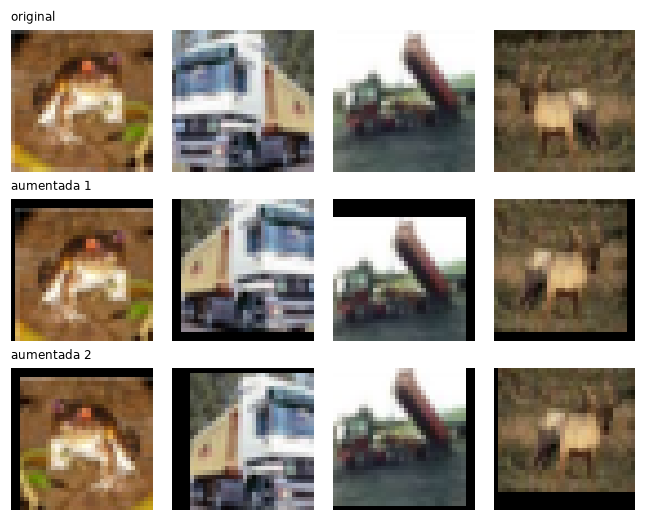

In [10]:
fijar_semilla()
orig = X_train_gpu[:4].float() / 255
fig, axes = plt.subplots(3, 4, figsize=(6, 4.8))
for fila in range(3):
    lote = orig if fila == 0 else aumentar_lote(orig)
    for j in range(4):
        axes[fila, j].imshow(lote[j].permute(1, 2, 0).cpu().numpy())
        axes[fila, j].axis("off")
    axes[fila, 0].set_title("original" if fila == 0 else f"aumentada {fila}", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## 3. Investigación: transfer learning en PyTorch

### torchvision.models.vgg16 y VGG16_Weights

torchvision.models.vgg16 construye la arquitectura VGG-16 de Simonyan y Zisserman. Su parámetro principal es weights: con None se inicializa aleatoriamente y con VGG16_Weights.IMAGENET1K_V1 o VGG16_Weights.DEFAULT descarga los pesos entrenados en ImageNet-1k, con 71.6 % de accuracy top-1. También acepta progress para mostrar la descarga y argumentos como num_classes, aunque con pesos preentrenados la cabeza debe quedarse en 1000 clases y reemplazarse después. VGG16_Weights es un enum que agrupa los pesos disponibles junto con sus metadatos: categorías, métricas, número de parámetros y la receta de preprocesamiento. weights.transforms devuelve ese preprocesamiento listo para usar: Resize a 256 con interpolación bilineal, CenterCrop a 224, conversión a [0, 1] y normalización con la media 0.485, 0.456, 0.406 y la desviación 0.229, 0.224, 0.225 de ImageNet.

### Estructura del modelo

VGG-16 se divide en tres atributos. model.features es un nn.Sequential de 31 módulos con 13 convoluciones 3x3 seguidas de ReLU y 5 MaxPool de 2x2, que forman 5 bloques de 64, 128, 256, 512 y 512 canales; cada MaxPool divide la resolución a la mitad, así que una entrada de 224 sale como un mapa de 512x7x7. model.avgpool es un nn.AdaptiveAvgPool2d con output_size de 7x7: fija el tamaño de salida sin importar la resolución de entrada, lo que permite usar entradas distintas de 224 sin romper el clasificador. model.classifier contiene Linear de 25,088 a 4,096, ReLU, Dropout de 0.5, Linear de 4,096 a 4,096, ReLU, Dropout y Linear de 4,096 a 1,000. Para CIFAR-10 se reemplaza model.classifier[6] por una capa de 10 salidas.

In [11]:
vgg_demo = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print(vgg_demo.avgpool)
print(vgg_demo.classifier)

BLOQUES_VGG = {1: (0, 5), 2: (5, 10), 3: (10, 17), 4: (17, 24), 5: (24, 31)}
for b, (ini, fin) in BLOQUES_VGG.items():
    convs = [m for m in vgg_demo.features[ini:fin] if isinstance(m, nn.Conv2d)]
    n_par = sum(p.numel() for p in vgg_demo.features[ini:fin].parameters())
    print(f"Bloque {b}: features[{ini}:{fin}] | {len(convs)} conv de {convs[0].out_channels} canales | {n_par:,} parámetros")
print(f"Clasificador: {sum(p.numel() for p in vgg_demo.classifier.parameters()):,} parámetros")

with torch.no_grad():
    for r in [224, 128, 32]:
        f = vgg_demo.features(torch.zeros(1, 3, r, r))
        print(f"entrada {r}x{r} -> features {tuple(f.shape[1:])} -> avgpool {tuple(vgg_demo.avgpool(f).shape[1:])}")

AdaptiveAvgPool2d(output_size=(7, 7))
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)
Bloque 1: features[0:5] | 2 conv de 64 canales | 38,720 parámetros
Bloque 2: features[5:10] | 2 conv de 128 canales | 221,440 parámetros
Bloque 3: features[10:17] | 3 conv de 256 canales | 1,475,328 parámetros
Bloque 4: features[17:24] | 3 conv de 512 canales | 5,899,776 parámetros
Bloque 5: features[24:31] | 3 conv de 512 canales | 7,079,424 parámetros
Clasificador: 123,642,856 parámetros
entrada 224x224 -> features (512, 7, 7) -> avgpool (512, 7, 7)
entrada 128x128 -> features (512, 4, 4) -> avgpool (512, 7, 7)
entrada 32x32 -> features (512, 1, 1) -> avgpool (512, 7, 7)


### requires_grad: congelar y descongelar

Cada parámetro de PyTorch es un tensor con el atributo requires_grad. Si vale False, autograd no calcula su gradiente y el optimizador no lo modifica, así que la capa queda congelada. Para congelar un bloque completo se recorre model.features[ini:fin].parameters y se asigna p.requires_grad = False, o se llama requires_grad_ del módulo. Descongelar es asignar True de nuevo. Además de fijar los pesos, congelar ahorra memoria y cómputo, porque no se guardan gradientes ni estado del optimizador para esas capas y el backward se detiene en la primera capa entrenable. Es buena práctica pasar al optimizador solo los parámetros con requires_grad en True.

In [12]:
def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables

vgg_demo.classifier[6] = nn.Linear(4096, 10)
vgg_demo.features.requires_grad_(False)
print("Feature extractor -> total %s | entrenables %s" % tuple(f"{n:,}" for n in contar_parametros(vgg_demo)))
ini, fin = BLOQUES_VGG[5]
vgg_demo.features[ini:fin].requires_grad_(True)
print("Fine-tuning b5     -> total %s | entrenables %s" % tuple(f"{n:,}" for n in contar_parametros(vgg_demo)))

Feature extractor -> total 134,301,514 | entrenables 119,586,826
Fine-tuning b5     -> total 134,301,514 | entrenables 126,666,250


### model.train, model.eval y torch.no_grad

model.train activa el comportamiento de entrenamiento: Dropout apaga neuronas al azar y BatchNorm normaliza con las estadísticas del lote y actualiza sus promedios móviles. model.eval desactiva Dropout y hace que BatchNorm use los promedios acumulados, de modo que la salida es determinista. Ninguno de los dos afecta el cálculo de gradientes. torch.no_grad es un contexto que evita construir el grafo computacional, lo que reduce memoria y tiempo; se usa en validación, test y medición de latencia. En evaluación se combinan ambos: model.eval para el comportamiento correcto de las capas y torch.no_grad para no gastar memoria en gradientes.

### Grupos de parámetros del optimizador

Los optimizadores de torch.optim aceptan una lista de diccionarios en lugar de una sola lista de parámetros. Cada diccionario es un grupo con su clave params y sus propios hiperparámetros, como lr o weight_decay; lo que no se especifique se toma de los valores por defecto del optimizador. Después de crearlo, optimizer.param_groups permite leer o modificar el learning rate de cada grupo, y los schedulers escalan cada grupo por separado. En fine-tuning se usa para dar un learning rate pequeño al backbone preentrenado y uno mayor al clasificador nuevo.

In [13]:
opt_demo = torch.optim.SGD([
    {"params": [p for p in vgg_demo.features.parameters() if p.requires_grad], "lr": 1e-3},
    {"params": vgg_demo.classifier.parameters(), "lr": 1e-2},
], momentum=0.9, weight_decay=5e-4)
for i, g in enumerate(opt_demo.param_groups):
    print(f"grupo {i}: lr = {g['lr']}, momentum = {g['momentum']}, tensores = {len(g['params'])}")
del opt_demo

grupo 0: lr = 0.001, momentum = 0.9, tensores = 6
grupo 1: lr = 0.01, momentum = 0.9, tensores = 6


### Herramientas para contar parámetros y operaciones

torchinfo.summary recibe el modelo e input_size, y con col_names y depth muestra por capa la forma de salida, el número de parámetros, si son entrenables y el total de mult-adds. thop.profile recibe el modelo e inputs, ejecuta un forward con hooks y devuelve los MACs y parámetros totales; aunque la librería se llama OpCounter, su resultado son MACs. En este laboratorio se usa torchinfo para la estructura y thop para el costo, y ambos se contrastan con un contador propio basado en hooks que además separa el costo de las capas entrenables.

In [14]:
print(summary(vgg_demo, input_size=(1, 3, 224, 224), depth=1,
              col_names=["output_size", "num_params", "trainable", "mult_adds"], device="cpu", verbose=0))
macs_thop, params_thop = profile(copy.deepcopy(vgg_demo), inputs=(torch.zeros(1, 3, 224, 224),), verbose=False)
print(f"thop -> MACs: {macs_thop / 1e9:.2f} G | FLOPs aprox.: {2 * macs_thop / 1e9:.2f} G | parámetros: {params_thop / 1e6:.2f} M")

Layer (type:depth-idx)                   Output Shape              Param #                   Trainable                 Mult-Adds
VGG                                      [1, 10]                   --                        Partial                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            14,714,688                Partial                   15,360,178,176
├─AdaptiveAvgPool2d: 1-2                 [1, 512, 7, 7]            --                        --                        --
├─Sequential: 1-3                        [1, 10]                   119,586,826               True                      119,586,826
Total params: 134,301,514
Trainable params: 126,666,250
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 15.48
Input size (MB): 0.60
Forward/backward pass size (MB): 108.45
Params size (MB): 537.21
Estimated Total Size (MB): 646.25


thop -> MACs: 15.47 G | FLOPs aprox.: 30.93 G | parámetros: 134.30 M


### Medición de memoria y tiempo en GPU

torch.cuda.max_memory_allocated devuelve el máximo de bytes ocupados por tensores desde el inicio del programa o desde el último torch.cuda.reset_peak_memory_stats; no incluye la memoria reservada en caché por el asignador ni el contexto de CUDA, que se consultan con memory_reserved o nvidia-smi. Recibe opcionalmente el dispositivo. torch.cuda.synchronize bloquea la CPU hasta que terminan todos los kernels pendientes. Es indispensable para medir tiempo porque las llamadas a CUDA son asíncronas: sin sincronizar, el cronómetro solo mide cuánto tardó la CPU en encolar las operaciones.

In [15]:
m = vgg_demo.to(DEVICE).eval()
x = torch.randn(64, 3, 224, 224, device=DEVICE)
with torch.no_grad():
    m(x); torch.cuda.synchronize()
    t0 = time.perf_counter(); m(x); t_sin = time.perf_counter() - t0
    torch.cuda.synchronize()
    t0 = time.perf_counter(); m(x); torch.cuda.synchronize(); t_con = time.perf_counter() - t0
print(f"forward de 64 imágenes sin synchronize: {t_sin * 1e3:.1f} ms | con synchronize: {t_con * 1e3:.1f} ms")
print(f"memoria pico hasta ahora: {torch.cuda.max_memory_allocated() / 2**20:.0f} MB")
del m, vgg_demo, x
torch.cuda.empty_cache()

forward de 64 imágenes sin synchronize: 12.2 ms | con synchronize: 73.0 ms
memoria pico hasta ahora: 6423 MB


### MACs frente a FLOPs y parámetros totales frente a entrenables

Un MAC, multiply-accumulate, es una multiplicación seguida de una suma, a por b más c, que es la operación básica de convoluciones y capas lineales. Un FLOP cuenta cada operación de punto flotante por separado, así que un MAC equivale a dos FLOPs y FLOPs es aproximadamente 2 por MACs. Muchas herramientas reportan MACs aunque los llamen FLOPs, por lo que siempre hay que revisar cuál unidad se usa. Para entrenamiento se usa la regla habitual de que el backward cuesta cerca del doble del forward, porque calcula el gradiente respecto a la entrada y respecto a los pesos de cada capa.

Los parámetros totales son todos los pesos del modelo y determinan el tamaño en disco, la memoria de inferencia y los FLOPs del forward. Los parámetros entrenables son solo los que tienen requires_grad en True: determinan cuántos gradientes y cuánto estado del optimizador hay que guardar, y hasta dónde llega el backward. En VGG-16 como feature extractor casi 15 millones de parámetros convolucionales se usan en cada forward pero nunca se actualizan.

## 4. Construcción y entrenamiento de los modelos

### 4.1 Utilidades de entrenamiento, evaluación y medición

Las funciones siguientes se usan en todas las iteraciones. El entrenamiento usa precisión mixta bfloat16 y formato channels_last para aprovechar los tensor cores de la GPU. En cada epoch se mide el tiempo de entrenamiento con torch.cuda.synchronize, se evalúa en validación y se guarda el estado del modelo con mejor F1 macro de validación. La memoria pico se mide con torch.cuda.max_memory_allocated reiniciando el contador al terminar la primera epoch, porque en ella cudnn.benchmark prueba algoritmos de convolución con buffers temporales que inflan el pico; incluye los 180 MB del dataset alojado en GPU, iguales para los tres modelos.

In [16]:
def iterar_lotes(X, y, indices, batch_size, barajar):
    idx = torch.as_tensor(indices, device=DEVICE)
    if barajar:
        idx = idx[torch.randperm(len(idx), device=DEVICE)]
    for i in range(0, len(idx), batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]

@torch.no_grad()
def evaluar(modelo, X, y, indices, cfg, batch_size=256):
    modelo.eval()
    perdida, preds = 0.0, []
    for xb, yb in iterar_lotes(X, y, indices, batch_size, barajar=False):
        x = preparar_lote(xb, cfg["modo"], aumentar=False, res=cfg.get("res", 32))
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logits = modelo(x)
        perdida += F.cross_entropy(logits.float(), yb, reduction="sum").item()
        preds.append(logits.argmax(1))
    y_pred = torch.cat(preds).cpu().numpy()
    y_true = y[torch.as_tensor(indices, device=DEVICE)].cpu().numpy()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"loss": perdida / len(indices), "accuracy": accuracy_score(y_true, y_pred),
            "precision": p, "recall": r, "f1": f1, "y_true": y_true, "y_pred": y_pred}

def crear_optimizador(modelo, cfg):
    if cfg.get("lr_backbone") is not None:
        grupos = [
            {"params": [p for p in modelo.features.parameters() if p.requires_grad], "lr": cfg["lr_backbone"]},
            {"params": [p for p in modelo.classifier.parameters() if p.requires_grad], "lr": cfg["lr"]},
        ]
    else:
        grupos = [{"params": [p for p in modelo.parameters() if p.requires_grad], "lr": cfg["lr"]}]
    if cfg["optim"] == "adam":
        return torch.optim.Adam(grupos, weight_decay=cfg.get("wd", 0.0))
    return torch.optim.SGD(grupos, momentum=0.9, nesterov=True, weight_decay=cfg.get("wd", 0.0))

def crear_scheduler(opt, cfg, pasos_totales):
    if cfg.get("sched") == "onecycle":
        return torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in opt.param_groups],
                                                   total_steps=pasos_totales, pct_start=0.25)
    if cfg.get("sched") == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pasos_totales)
    return None

In [17]:
class CNNDesdeCero(nn.Module):
    def __init__(self, anchos=(64, 128, 256), convs_por_bloque=2, batchnorm=True,
                 dropout_conv=0.1, dropout_fc=0.3, fc=256, n_clases=10):
        super().__init__()
        capas, c_in = [], 3
        for c in anchos:
            for j in range(convs_por_bloque):
                capas.append(nn.Conv2d(c_in if j == 0 else c, c, 3, padding=1, bias=not batchnorm))
                if batchnorm:
                    capas.append(nn.BatchNorm2d(c))
                capas.append(nn.ReLU(inplace=True))
            capas.append(nn.MaxPool2d(2))
            if dropout_conv > 0:
                capas.append(nn.Dropout(dropout_conv))
            c_in = c
        self.features = nn.Sequential(*capas)
        lado = 32 // 2 ** len(anchos)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(c_in * lado * lado, fc), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc), nn.Linear(fc, n_clases))

    def forward(self, x):
        return self.classifier(self.features(x))

def construir_vgg(bloques_descongelados=()):
    modelo = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    modelo.features.requires_grad_(False)
    for b in bloques_descongelados:
        ini, fin = BLOQUES_VGG[b]
        modelo.features[ini:fin].requires_grad_(True)
    modelo.classifier[6] = nn.Linear(4096, 10)
    return modelo

def construir_modelo(cfg):
    fijar_semilla()
    if cfg["modo"] == "cnn":
        modelo = CNNDesdeCero(**cfg["arq"])
    else:
        modelo = construir_vgg(cfg.get("bloques", ()))
    return modelo.to(DEVICE).to(memory_format=torch.channels_last)

def descripcion_congeladas(cfg):
    if cfg["modo"] == "cnn":
        return "ninguna"
    libres = cfg.get("bloques", ())
    congelados = [str(b) for b in range(1, 6) if b not in libres]
    return "bloques " + ", ".join(congelados) if congelados else "ninguna"

In [18]:
def log(msg):
    print(msg)
    with open("resultados/entrenamiento.log", "a", encoding="utf-8") as f:
        print(msg, file=f)

REGISTROS = []
MEJOR_POR_FAMILIA = {}

def entrenar(nombre, familia, cfg, idx_tr=idx_train, guardar=True, verbose=True):
    fijar_semilla()
    modelo = construir_modelo(cfg)
    total, entrenables = contar_parametros(modelo)
    opt = crear_optimizador(modelo, cfg)
    n_epochs = cfg["epochs"]
    pasos = n_epochs * int(np.ceil(len(idx_tr) / cfg["batch"]))
    sched = crear_scheduler(opt, cfg, pasos)

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    hist = {k: [] for k in ["train_loss", "val_loss", "val_acc", "val_prec", "val_rec", "val_f1", "t_epoch"]}
    mejor_f1, mejor_estado, mejor_epoch = -1, None, 0

    for epoch in range(1, n_epochs + 1):
        modelo.train()
        torch.cuda.synchronize(); t0 = time.perf_counter()
        suma, n = torch.zeros((), device=DEVICE), 0
        for xb, yb in iterar_lotes(X_train_gpu, y_train_gpu, idx_tr, cfg["batch"], barajar=True):
            x = preparar_lote(xb, cfg["modo"], aumentar=cfg["aumento"], res=cfg.get("res", 32))
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = modelo(x)
            loss = F.cross_entropy(logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            if sched is not None:
                sched.step()
            suma += loss.detach() * len(yb); n += len(yb)
        torch.cuda.synchronize(); t_epoch = time.perf_counter() - t0

        val = evaluar(modelo, X_train_gpu, y_train_gpu, idx_val, cfg)
        for k, v in zip(hist.keys(), [(suma / n).item(), val["loss"], val["accuracy"], val["precision"],
                                      val["recall"], val["f1"], t_epoch]):
            hist[k].append(v)
        if val["f1"] > mejor_f1:
            mejor_f1, mejor_epoch = val["f1"], epoch
            mejor_estado = {k: v.detach().to("cpu", copy=True) for k, v in modelo.state_dict().items()}
        if verbose or epoch == n_epochs:
            log(f"[{nombre}] epoch {epoch:2d}/{n_epochs} | train loss {hist['train_loss'][-1]:.4f} | "
                  f"val loss {val['loss']:.4f} | val acc {val['accuracy']:.4f} | val F1 {val['f1']:.4f} | {t_epoch:.1f} s")
        if epoch == 1 and n_epochs > 1:
            torch.cuda.reset_peak_memory_stats()

    reg = {
        "nombre": nombre, "familia": familia, "cfg": cfg, "params_total": total, "params_entrenables": entrenables,
        "congeladas": descripcion_congeladas(cfg), "hist": hist, "mejor_epoch": mejor_epoch,
        "val": {k: hist[m][mejor_epoch - 1] for k, m in [("accuracy", "val_acc"), ("precision", "val_prec"),
                                                          ("recall", "val_rec"), ("f1", "val_f1"), ("loss", "val_loss")]},
        "t_epoch": float(np.mean(hist["t_epoch"])), "t_total": float(np.sum(hist["t_epoch"])),
        "mem_pico_mb": torch.cuda.max_memory_allocated() / 2**20, "n_train": len(idx_tr), "epochs": n_epochs,
    }
    if guardar:
        REGISTROS.append(reg)
        actual = MEJOR_POR_FAMILIA.get(familia)
        elegible = not cfg.get("exploratoria", False)
        if elegible and (actual is None or reg["val"]["f1"] > next(r for r in REGISTROS if r["nombre"] == actual)["val"]["f1"]):
            MEJOR_POR_FAMILIA[familia] = nombre
            torch.save(mejor_estado, f"checkpoints/{familia}_mejor.pt")
        guardar_registros()
    del modelo, opt
    torch.cuda.empty_cache()
    return reg, mejor_estado

def guardar_registros():
    with open("resultados/iteraciones.json", "w", encoding="utf-8") as f:
        json.dump({"registros": REGISTROS, "mejor": MEJOR_POR_FAMILIA, "hardware": HARDWARE}, f, indent=1, default=str)

def resumen_config(cfg):
    partes = []
    if cfg["modo"] == "cnn":
        a = cfg["arq"]
        partes.append(f"{len(a['anchos'])} bloques {'-'.join(map(str, a['anchos']))}, {a['convs_por_bloque']} conv/bloque")
        partes.append("BN" if a["batchnorm"] else "sin BN")
        partes.append(f"dropout {a['dropout_conv']}/{a['dropout_fc']}")
    else:
        partes.append(f"res {cfg['res']}")
        if cfg.get("bloques"):
            partes.append("descongela " + "+".join(f"b{b}" for b in cfg["bloques"]))
    partes.append(f"{cfg['optim']} lr {cfg['lr']:g}" + (f", lr backbone {cfg['lr_backbone']:g}" if cfg.get("lr_backbone") else ""))
    if cfg.get("wd"): partes.append(f"wd {cfg['wd']:g}")
    partes.append(cfg.get("sched") or "lr fijo")
    partes.append("con aumento" if cfg["aumento"] else "sin aumento")
    partes.append(f"{cfg['epochs']} epochs, batch {cfg['batch']}")
    return ", ".join(partes)

In [19]:
def contar_macs(modelo, res):
    macs = []
    def hook(m, entrada, salida):
        if isinstance(m, nn.Conv2d):
            n = salida.numel() * (m.in_channels // m.groups) * m.kernel_size[0] * m.kernel_size[1]
        else:
            n = salida.numel() * m.in_features
        macs.append((n, m.weight.requires_grad))
    hooks = [m.register_forward_hook(hook) for m in modelo.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
    modelo.eval()
    with torch.no_grad():
        modelo(torch.zeros(1, 3, res, res, device=DEVICE))
    for h in hooks: h.remove()
    total = sum(n for n, _ in macs)
    entrenable = sum(n for n, t in macs if t)
    return total, entrenable

@torch.no_grad()
def medir_latencia(modelo, res, n_rep=100, batch=1, repeticiones=7):
    m = copy.deepcopy(modelo).to(dtype=torch.bfloat16).eval()
    x = torch.randn(batch, 3, res, res, device=DEVICE, dtype=torch.bfloat16).contiguous(memory_format=torch.channels_last)
    tiempos = []
    for _ in range(30):
        m(x)
    for _ in range(repeticiones):
        torch.cuda.synchronize(); t0 = time.perf_counter()
        for _ in range(n_rep):
            m(x)
        torch.cuda.synchronize()
        tiempos.append((time.perf_counter() - t0) / n_rep * 1000 / batch)
    del m
    return float(np.median(tiempos))

def graficar_curvas(nombres, titulo, archivo):
    regs = [next(r for r in REGISTROS if r["nombre"] == n) for n in nombres]
    ncols = min(len(regs), 3)
    nrows = int(np.ceil(len(regs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.1 * nrows), sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax in axes[len(regs):]:
        ax.set_visible(False)
    for ax, r in zip(axes, regs):
        ep = np.arange(1, len(r["hist"]["train_loss"]) + 1)
        ax.plot(ep, r["hist"]["train_loss"], color=COLOR_TRAIN, label="train")
        ax.plot(ep, r["hist"]["val_loss"], color=COLOR_VAL, label="validación")
        ax.axvline(r["mejor_epoch"], color="#8a8984", lw=1, ls="--")
        ax.set_title(f"{r['nombre']}: val F1 {r['val']['f1']:.3f}", fontsize=10, loc="left")
        ax.set_xlabel("epoch")
    for ax in axes[::ncols]:
        ax.set_ylabel("cross-entropy loss")
    axes[0].legend(frameon=False)
    fig.suptitle(titulo, x=0.01, ha="left")
    plt.tight_layout(); plt.savefig(f"figuras/{archivo}"); plt.show()

def tabla_iteraciones(familia):
    filas = []
    for r in REGISTROS:
        if r["familia"] != familia: continue
        filas.append({
            "iteración": r["nombre"], "configuración": resumen_config(r["cfg"]), "capas congeladas": r["congeladas"],
            "params totales": f"{r['params_total']:,}", "params entrenables": f"{r['params_entrenables']:,}",
            "mejor epoch": r["mejor_epoch"], "val acc": round(r["val"]["accuracy"], 4),
            "val precision": round(r["val"]["precision"], 4), "val recall": round(r["val"]["recall"], 4),
            "val F1": round(r["val"]["f1"], 4), "s/epoch": round(r["t_epoch"], 1),
            "tiempo total s": round(r["t_total"], 1), "memoria pico MB": round(r["mem_pico_mb"]),
        })
    df = pd.DataFrame(filas)
    with pd.option_context("display.max_colwidth", None):
        display(df)
    return df

### 4.2 CNN desde cero

La primera iteración es una línea base sencilla sin batch normalization, dropout ni augmentation, para observar el overfitting. Las siguientes agregan esas técnicas, cambian el optimizador a SGD con Nesterov y OneCycle, y prueban una cuarta capa convolucional más ancha.

In [20]:
CFG_CNN = {
    "C1": {"modo": "cnn", "arq": dict(anchos=(32, 64, 128), convs_por_bloque=1, batchnorm=False, dropout_conv=0.0, dropout_fc=0.0),
           "optim": "adam", "lr": 1e-3, "wd": 0.0, "sched": None, "aumento": False, "epochs": 20, "batch": 128},
    "C2": {"modo": "cnn", "arq": dict(anchos=(64, 128, 256), convs_por_bloque=2, batchnorm=True, dropout_conv=0.1, dropout_fc=0.3),
           "optim": "adam", "lr": 1e-3, "wd": 0.0, "sched": "cosine", "aumento": True, "epochs": 30, "batch": 128},
    "C3": {"modo": "cnn", "arq": dict(anchos=(64, 128, 256), convs_por_bloque=2, batchnorm=True, dropout_conv=0.1, dropout_fc=0.3),
           "optim": "sgd", "lr": 0.1, "wd": 5e-4, "sched": "onecycle", "aumento": True, "epochs": 40, "batch": 128},
    "C4": {"modo": "cnn", "arq": dict(anchos=(64, 128, 256, 512), convs_por_bloque=2, batchnorm=True, dropout_conv=0.1, dropout_fc=0.4),
           "optim": "sgd", "lr": 0.1, "wd": 5e-4, "sched": "onecycle", "aumento": True, "epochs": 40, "batch": 128},
}
for nombre, cfg in CFG_CNN.items():
    print("=" * 20, nombre, "|", resumen_config(cfg))
    entrenar(nombre, "cnn", cfg)

==================== C1 | 3 bloques 32-64-128, 1 conv/bloque, sin BN, dropout 0.0/0.0, adam lr 0.001, lr fijo, sin aumento, 20 epochs, batch 128


[C1] epoch  1/20 | train loss 1.4491 | val loss 1.1242 | val acc 0.6000 | val F1 0.5955 | 2.9 s


[C1] epoch  2/20 | train loss 1.0055 | val loss 0.9284 | val acc 0.6692 | val F1 0.6655 | 0.7 s


[C1] epoch  3/20 | train loss 0.8107 | val loss 0.8187 | val acc 0.7110 | val F1 0.7102 | 0.7 s


[C1] epoch  4/20 | train loss 0.6739 | val loss 0.8020 | val acc 0.7196 | val F1 0.7197 | 0.7 s


...

[C4] epoch 36/40 | train loss 0.1075 | val loss 0.2701 | val acc 0.9218 | val F1 0.9219 | 1.6 s


[C4] epoch 37/40 | train loss 0.0848 | val loss 0.2641 | val acc 0.9266 | val F1 0.9264 | 1.6 s


[C4] epoch 38/40 | train loss 0.0720 | val loss 0.2565 | val acc 0.9294 | val F1 0.9294 | 1.5 s


[C4] epoch 39/40 | train loss 0.0592 | val loss 0.2556 | val acc 0.9284 | val F1 0.9284 | 1.6 s


[C4] epoch 40/40 | train loss 0.0564 | val loss 0.2550 | val acc 0.9314 | val F1 0.9315 | 1.6 s


,iteración,configuración,capas congeladas,params totales,params entrenables,mejor epoch,val acc,val precision,val recall,val F1,s/epoch,tiempo total s,memoria pico MB
0,C1,"3 bloques 32-64-128, 1 conv/bloque, sin BN, dropout 0.0/0.0, adam lr 0.001, lr fijo, sin aumento, 20 epochs, batch 128",ninguna,"620,362","620,362",12,0.7620,0.7640,0.7620,0.7619,0.8,16.2,805
1,C2,"3 bloques 64-128-256, 2 conv/bloque, BN, dropout 0.1/0.3, adam lr 0.001, cosine, con aumento, 30 epochs, batch 128",ninguna,"2,197,706","2,197,706",30,0.9034,0.9034,0.9034,0.9033,1.3,39.7,950
2,C3,"3 bloques 64-128-256, 2 conv/bloque, BN, dropout 0.1/0.3, sgd lr 0.1, wd 0.0005, onecycle, con aumento, 40 epochs, batch 128",ninguna,"2,197,706","2,197,706",40,0.9264,0.9262,0.9264,0.9262,1.2,48.9,942
3,C4,"4 bloques 64-128-256-512, 2 conv/bloque, BN, dropout 0.1/0.4, sgd lr 0.1, wd 0.0005, onecycle, con aumento, 40 epochs, batch 128",ninguna,"5,214,410","5,214,410",40,0.9314,0.9316,0.9314,0.9315,1.6,64.6,993


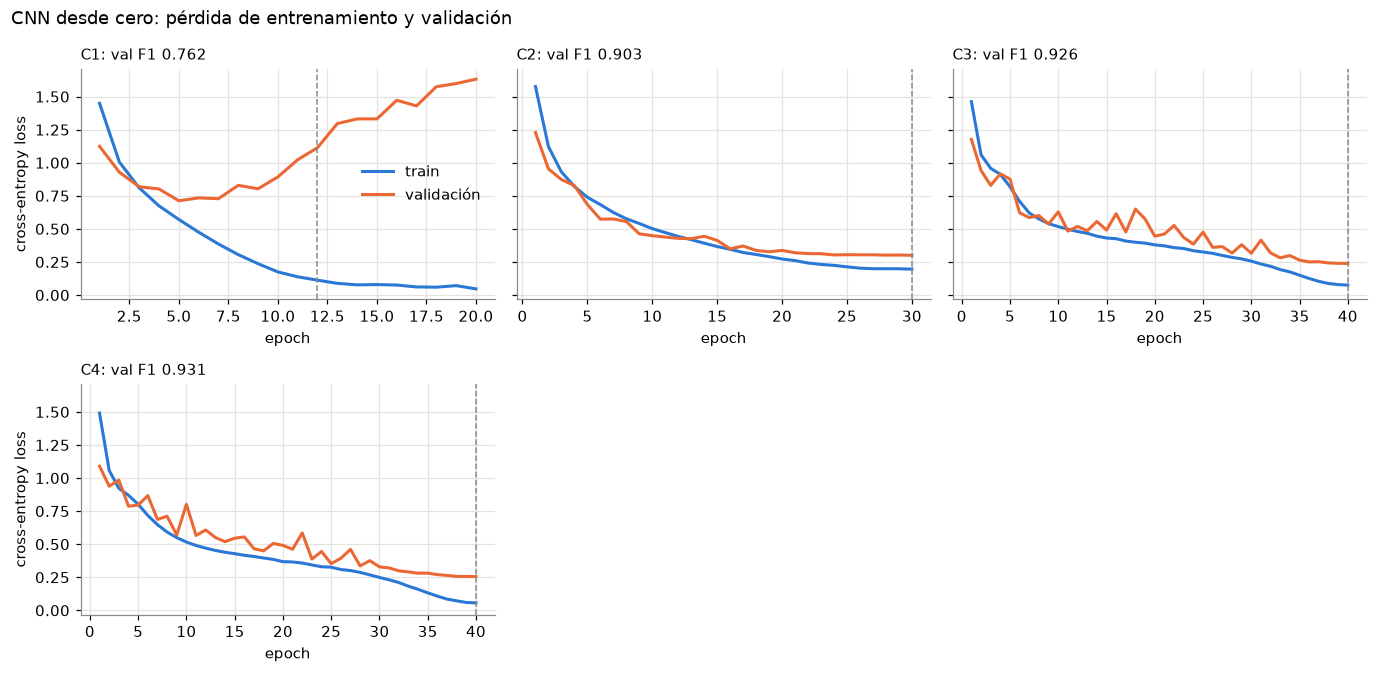

In [21]:
tabla_cnn = tabla_iteraciones("cnn")
graficar_curvas(list(CFG_CNN), "CNN desde cero: pérdida de entrenamiento y validación", "curvas_cnn.png")

La línea discontinua marca la epoch con mejor F1 de validación, cuyo checkpoint es el que se conserva.

C1 muestra un overfitting claro: la pérdida de entrenamiento baja hasta 0.05 mientras la de validación toca su mínimo de 0.71 en la epoch 5 y luego sube hasta 1.63, con la accuracy de validación estancada cerca de 76 %. Al agregar batch normalization, dropout y augmentation en C2, la brecha desaparece y la validación sube a 90.3 %, con ambas curvas bajando juntas. C3 conserva la arquitectura y cambia a SGD con Nesterov, OneCycle y weight decay; durante la fase de learning rate alto la validación oscila, pero al bajar el learning rate converge a 92.6 %. C4 agrega un cuarto bloque de 512 canales y logra el mejor resultado, 93.1 %, con 5.2 millones de parámetros. En C2, C3 y C4 la mejor epoch es la última, lo que indica que no hay overfitting y que un entrenamiento más largo podría mejorar un poco más.

### 4.3 VGG-16 como feature extractor

Los 13 bloques convolucionales quedan congelados y solo se entrenan las tres capas lineales del clasificador, con la última reemplazada por una de 10 salidas. Se prueban Adam con dos learning rates y SGD con momentum. La iteración F4 repite la mejor configuración a 128x128; es exploratoria, sirve para medir el efecto de la resolución y no compite por la mejor configuración, porque ambos modelos VGG-16 deben usar la misma resolución de 224x224.

In [22]:
CFG_FE = {
    "F1": {"modo": "vgg", "res": RES_VGG, "bloques": (), "optim": "adam", "lr": 1e-3, "wd": 0.0, "sched": None,
           "aumento": False, "epochs": 8, "batch": 128},
    "F2": {"modo": "vgg", "res": RES_VGG, "bloques": (), "optim": "adam", "lr": 1e-4, "wd": 0.0, "sched": "cosine",
           "aumento": True, "epochs": 8, "batch": 128},
    "F3": {"modo": "vgg", "res": RES_VGG, "bloques": (), "optim": "sgd", "lr": 1e-2, "wd": 5e-4, "sched": "cosine",
           "aumento": True, "epochs": 8, "batch": 128},
}
for nombre, cfg in CFG_FE.items():
    print("=" * 20, nombre, "|", resumen_config(cfg))
    entrenar(nombre, "fe", cfg)

cfg_f4 = dict(CFG_FE[MEJOR_POR_FAMILIA["fe"]], res=128, exploratoria=True)
CFG_FE["F4"] = cfg_f4
print("=" * 20, "F4 |", resumen_config(cfg_f4), f"| basada en {MEJOR_POR_FAMILIA['fe']}")
_ = entrenar("F4", "fe", cfg_f4)

==================== F1 | res 224, adam lr 0.001, lr fijo, sin aumento, 8 epochs, batch 128


[F1] epoch  1/8 | train loss 0.6270 | val loss 0.4533 | val acc 0.8426 | val F1 0.8400 | 33.3 s


[F1] epoch  2/8 | train loss 0.4009 | val loss 0.3950 | val acc 0.8756 | val F1 0.8750 | 32.0 s


[F1] epoch  3/8 | train loss 0.3199 | val loss 0.3765 | val acc 0.8754 | val F1 0.8757 | 32.6 s


[F1] epoch  4/8 | train loss 0.2717 | val loss 0.4249 | val acc 0.8748 | val F1 0.8752 | 32.4 s


...

[F4] epoch  4/8 | train loss 0.3516 | val loss 0.3171 | val acc 0.8906 | val F1 0.8906 | 13.0 s


[F4] epoch  5/8 | train loss 0.3112 | val loss 0.3036 | val acc 0.8944 | val F1 0.8943 | 13.0 s


[F4] epoch  6/8 | train loss 0.2813 | val loss 0.2986 | val acc 0.8976 | val F1 0.8974 | 13.0 s


[F4] epoch  7/8 | train loss 0.2636 | val loss 0.2957 | val acc 0.8976 | val F1 0.8974 | 13.0 s


[F4] epoch  8/8 | train loss 0.2553 | val loss 0.2934 | val acc 0.8992 | val F1 0.8991 | 13.0 s


,iteración,configuración,capas congeladas,params totales,params entrenables,mejor epoch,val acc,val precision,val recall,val F1,s/epoch,tiempo total s,memoria pico MB
0,F1,"res 224, adam lr 0.001, lr fijo, sin aumento, 8 epochs, batch 128","bloques 1, 2, 3, 4, 5","134,301,514","119,586,826",8,0.8826,0.8882,0.8826,0.8835,32.5,259.9,6354
1,F2,"res 224, adam lr 0.0001, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3, 4, 5","134,301,514","119,586,826",8,0.9084,0.9088,0.9084,0.9084,31.0,247.8,6354
2,F3,"res 224, sgd lr 0.01, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3, 4, 5","134,301,514","119,586,826",8,0.9038,0.9039,0.9038,0.9037,29.2,233.4,5898
3,F4,"res 128, adam lr 0.0001, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3, 4, 5","134,301,514","119,586,826",8,0.8992,0.8991,0.8992,0.8991,13.1,104.9,3851


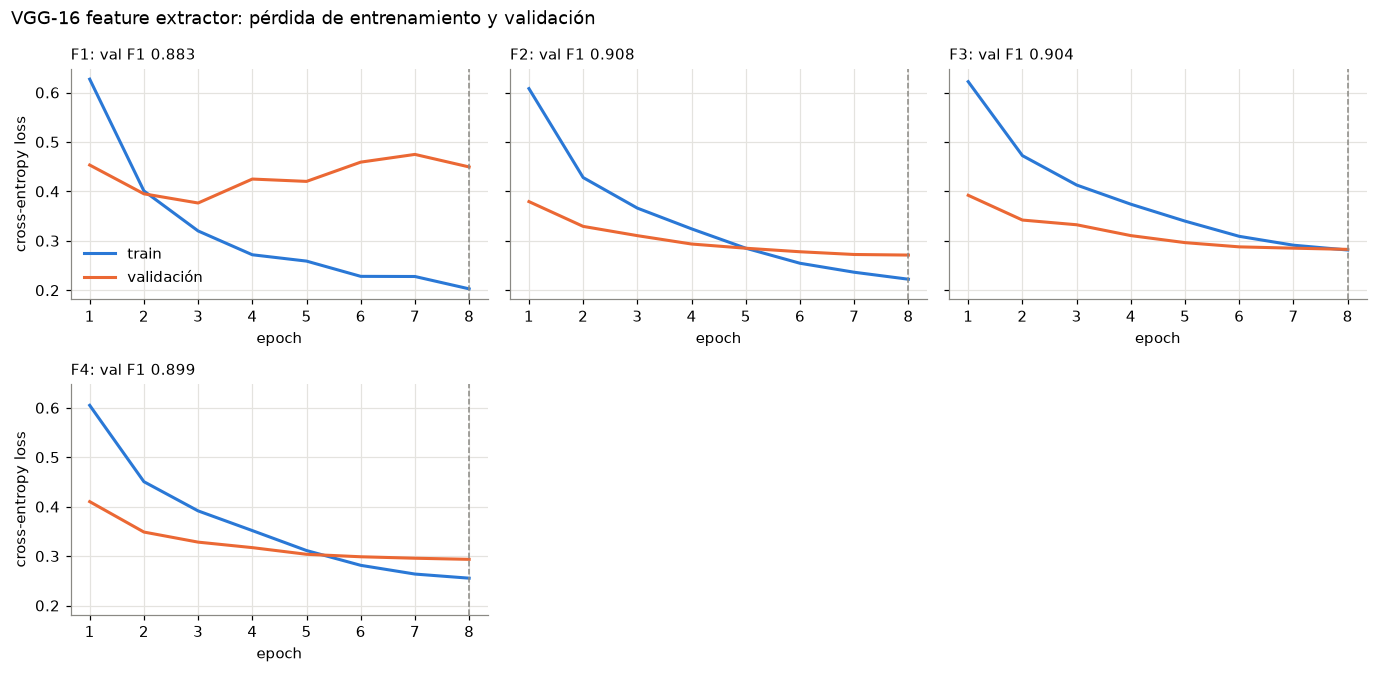

In [23]:
tabla_fe = tabla_iteraciones("fe")
graficar_curvas(list(CFG_FE), "VGG-16 feature extractor: pérdida de entrenamiento y validación", "curvas_fe.png")

F1, con Adam a 0.001 y sin augmentation, sobreajusta desde la epoch 3: la pérdida de validación sube de 0.38 a 0.45 mientras la de entrenamiento sigue bajando, porque las capas densas de 120 millones de parámetros memorizan con facilidad. Bajar el learning rate a 0.0001 y agregar augmentation en F2 elimina ese problema y da el mejor feature extractor, 90.8 % de accuracy de validación. F3 con SGD queda cerca, en 90.4 %, y usa unos 450 MB menos de memoria, porque SGD con momentum guarda un tensor de estado por parámetro y Adam guarda dos. F4 muestra el efecto de la resolución: a 128x128 pierde solo 0.9 puntos frente a F2, pero cada epoch tarda 13.1 s en lugar de 31.0 s y la memoria pico baja de 6.4 a 3.9 GB. Aun así, el feature extractor queda por debajo de la CNN desde cero: las features congeladas de ImageNet no se adaptan a imágenes de 32x32 ampliadas.

### 4.4 VGG-16 con fine-tuning

Se parte del mismo modelo preentrenado y se descongelan uno, dos o tres bloques superiores, entrenándolos junto con el clasificador. Se usa SGD con Nesterov y cosine annealing, con learning rate de 0.01 en el clasificador, el valor que funcionó en el feature extractor, y uno menor en el backbone mediante param_groups. T1 a T3 varían el número de bloques descongelados con el mismo learning rate de backbone; T4 y T5 fijan los bloques 4 y 5 y varían ese learning rate hacia abajo y hacia arriba, para observar el efecto sobre las features preentrenadas. T5 usa en el backbone el mismo learning rate del clasificador, así que no cumple la condición de un learning rate menor para el backbone: es un control exploratorio y no compite por la mejor configuración. T6 combina lo aprendido: descongela los bloques 3 a 5 como T3 y usa un learning rate de backbone intermedio de 0.003, todavía menor que el del clasificador.

In [24]:
base_ft = {"modo": "vgg", "res": RES_VGG, "optim": "sgd", "lr": 1e-2, "wd": 5e-4, "sched": "cosine",
           "aumento": True, "epochs": 8, "batch": 128}
CFG_FT = {
    "T1": dict(base_ft, bloques=(5,), lr_backbone=1e-3),
    "T2": dict(base_ft, bloques=(4, 5), lr_backbone=1e-3),
    "T3": dict(base_ft, bloques=(3, 4, 5), lr_backbone=1e-3),
    "T4": dict(base_ft, bloques=(4, 5), lr_backbone=1e-4),
    "T5": dict(base_ft, bloques=(4, 5), lr_backbone=1e-2, exploratoria=True),
    "T6": dict(base_ft, bloques=(3, 4, 5), lr_backbone=3e-3),
}
for nombre, cfg in CFG_FT.items():
    print("=" * 20, nombre, "|", resumen_config(cfg))
    entrenar(nombre, "ft", cfg)

==================== T1 | res 224, descongela b5, sgd lr 0.01, lr backbone 0.001, wd 0.0005, cosine, con aumento, 8 epochs, batch 128


[T1] epoch  1/8 | train loss 0.5290 | val loss 0.3324 | val acc 0.8872 | val F1 0.8859 | 31.8 s


[T1] epoch  2/8 | train loss 0.3488 | val loss 0.2694 | val acc 0.9072 | val F1 0.9070 | 32.0 s


[T1] epoch  3/8 | train loss 0.2857 | val loss 0.2575 | val acc 0.9116 | val F1 0.9111 | 32.2 s


[T1] epoch  4/8 | train loss 0.2466 | val loss 0.2462 | val acc 0.9178 | val F1 0.9175 | 32.7 s


...

[T6] epoch  4/8 | train loss 0.1410 | val loss 0.1794 | val acc 0.9430 | val F1 0.9429 | 52.9 s


[T6] epoch  5/8 | train loss 0.1018 | val loss 0.1847 | val acc 0.9430 | val F1 0.9431 | 55.5 s


[T6] epoch  6/8 | train loss 0.0822 | val loss 0.1743 | val acc 0.9476 | val F1 0.9477 | 53.1 s


[T6] epoch  7/8 | train loss 0.0659 | val loss 0.1731 | val acc 0.9498 | val F1 0.9497 | 56.9 s


[T6] epoch  8/8 | train loss 0.0593 | val loss 0.1724 | val acc 0.9500 | val F1 0.9500 | 62.3 s


,iteración,configuración,capas congeladas,params totales,params entrenables,mejor epoch,val acc,val precision,val recall,val F1,s/epoch,tiempo total s,memoria pico MB
0,T1,"res 224, descongela b5, sgd lr 0.01, lr backbone 0.001, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3, 4","134,301,514","126,666,250",8,0.9266,0.9263,0.9266,0.9264,32.1,257.0,5952
1,T2,"res 224, descongela b4+b5, sgd lr 0.01, lr backbone 0.001, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3","134,301,514","132,566,026",6,0.9376,0.9379,0.9376,0.9377,41.6,332.8,5997
2,T3,"res 224, descongela b3+b4+b5, sgd lr 0.01, lr backbone 0.001, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2","134,301,514","134,041,354",8,0.9460,0.9460,0.9460,0.9460,51.3,410.6,6011
3,T4,"res 224, descongela b4+b5, sgd lr 0.01, lr backbone 0.0001, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3","134,301,514","132,566,026",6,0.9204,0.9208,0.9204,0.9201,41.1,328.5,5997
4,T5,"res 224, descongela b4+b5, sgd lr 0.01, lr backbone 0.01, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2, 3","134,301,514","132,566,026",8,0.9490,0.9491,0.9490,0.9490,41.2,329.5,5997
5,T6,"res 224, descongela b3+b4+b5, sgd lr 0.01, lr backbone 0.003, wd 0.0005, cosine, con aumento, 8 epochs, batch 128","bloques 1, 2","134,301,514","134,041,354",8,0.9500,0.9500,0.9500,0.9500,55.4,443.3,6011


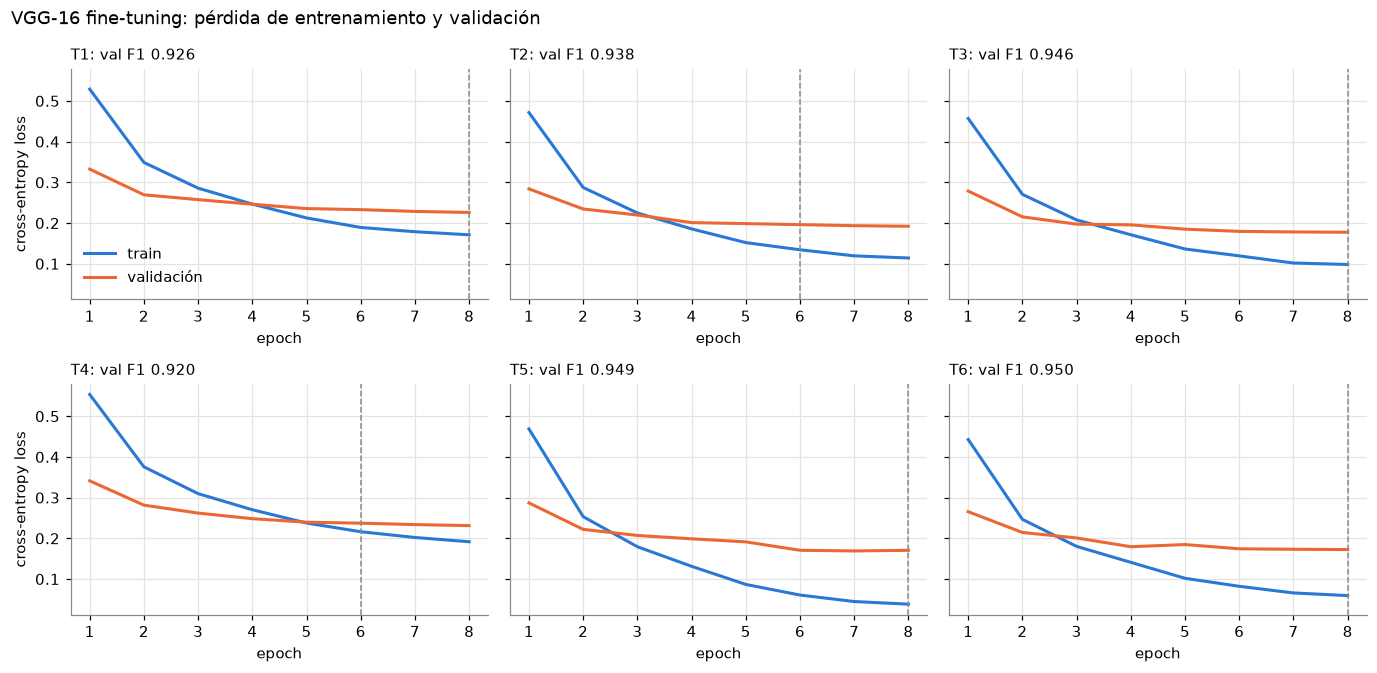

In [25]:
tabla_ft = tabla_iteraciones("ft")
graficar_curvas(list(CFG_FT), "VGG-16 fine-tuning: pérdida de entrenamiento y validación", "curvas_ft.png")

El número de bloques descongelados tiene un efecto directo con el mismo learning rate de backbone de 0.001: con el bloque 5 la validación llega a 92.6 %, con los bloques 4 y 5 a 93.8 % y con los bloques 3 a 5 a 94.6 %. Cada bloque adicional agrega tiempo por epoch, de 32 a 42 y 51 s, pero casi no cambia la memoria pico, que se mantiene cerca de 6 GB porque los bloques convolucionales tienen pocos parámetros frente al clasificador.

El learning rate del backbone también importa. Con 0.0001 en T4 los bloques casi no se adaptan y el resultado cae a 92.0 %, incluso por debajo de descongelar solo el bloque 5 con 0.001. Con 0.01 en T5, igual al del clasificador, la validación sube a 94.9 %, pero la pérdida de entrenamiento baja hasta 0.04 frente a 0.17 en validación, la brecha más grande entre las iteraciones de fine-tuning, lo que es una señal temprana de overfitting. No se observó catastrophic forgetting: incluso con el learning rate más alto la accuracy de la primera epoch es de 90 %, similar a la de las demás iteraciones, y la pérdida de validación no muestra un aumento sostenido. T6 combina los bloques 3 a 5 con un learning rate intermedio de 0.003 y obtiene el mejor resultado elegible, 95.0 %, con una brecha menor que T5.

### 4.5 Evaluación final sobre test

Con la mejor iteración de cada modelo según el F1 macro de validación se carga su checkpoint y se evalúa una única vez sobre el conjunto de test oficial.

Mejor iteración por modelo: {'cnn': 'C4', 'fe': 'F2', 'ft': 'T6'}


CNN desde cero             [C4] test acc 0.9292 | precision 0.9291 | recall 0.9292 | F1 0.9291


VGG-16 feature extractor   [F2] test acc 0.8953 | precision 0.8953 | recall 0.8953 | F1 0.8952


VGG-16 fine-tuning         [T6] test acc 0.9420 | precision 0.9418 | recall 0.9420 | F1 0.9419


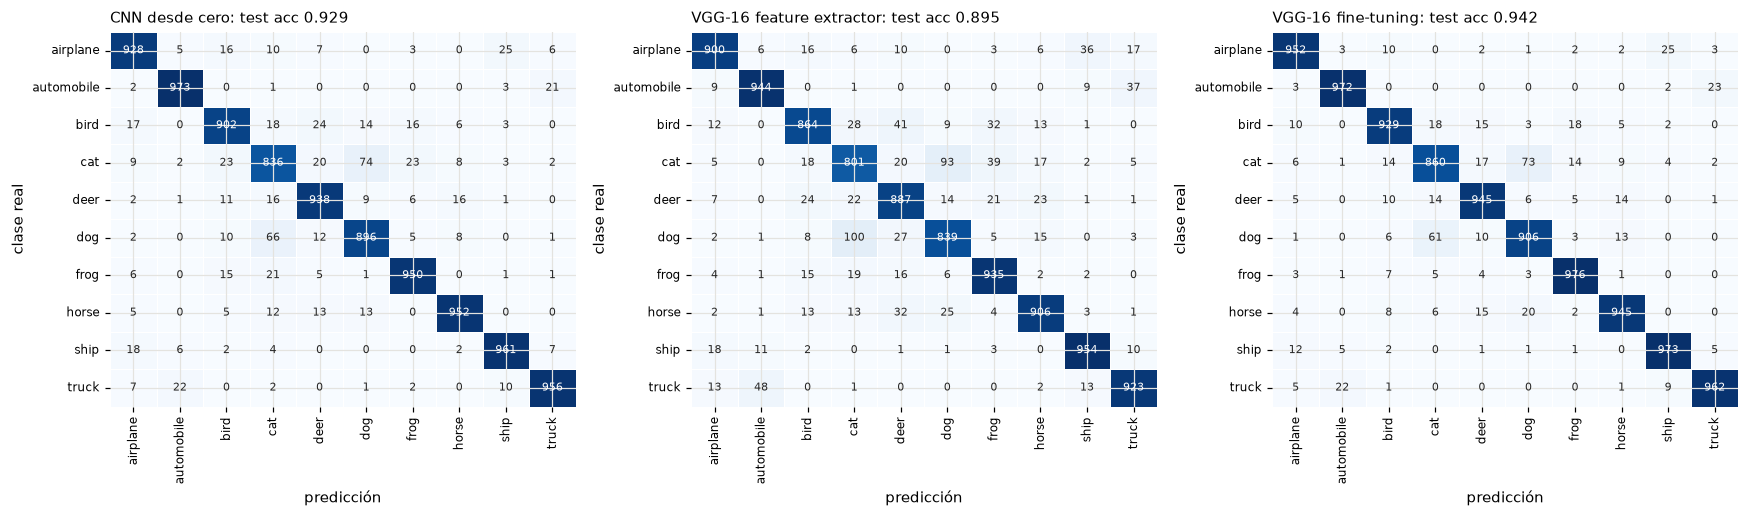

In [26]:
print("Mejor iteración por modelo:", MEJOR_POR_FAMILIA)
CFG_TODAS = {**CFG_CNN, **CFG_FE, **CFG_FT}
RES_TEST, MODELOS_FINALES = {}, {}
idx_test = np.arange(len(y_test))
for fam in ["cnn", "fe", "ft"]:
    nombre = MEJOR_POR_FAMILIA[fam]
    cfg = CFG_TODAS[nombre]
    modelo = construir_modelo(cfg)
    modelo.load_state_dict(torch.load(f"checkpoints/{fam}_mejor.pt"))
    RES_TEST[fam] = evaluar(modelo, X_test_gpu, y_test_gpu, idx_test, cfg)
    MODELOS_FINALES[fam] = modelo
    r = RES_TEST[fam]
    print(f"{NOMBRE_FAMILIA[fam]:26s} [{nombre}] test acc {r['accuracy']:.4f} | precision {r['precision']:.4f} | "
          f"recall {r['recall']:.4f} | F1 {r['f1']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, fam in zip(axes, ["cnn", "fe", "ft"]):
    cm = confusion_matrix(RES_TEST[fam]["y_true"], RES_TEST[fam]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 7},
                xticklabels=CLASES, yticklabels=CLASES, linewidths=0.5, linecolor="white")
    ax.set_title(f"{NOMBRE_FAMILIA[fam]}: test acc {RES_TEST[fam]['accuracy']:.3f}", fontsize=10, loc="left")
    ax.set_xlabel("predicción"); ax.set_ylabel("clase real")
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.savefig("figuras/matrices_confusion.png"); plt.show()

In [27]:
def pares_confundidos(fam, k=5):
    cm = confusion_matrix(RES_TEST[fam]["y_true"], RES_TEST[fam]["y_pred"])
    pares = [(CLASES[i], CLASES[j], cm[i, j] + cm[j, i]) for i in range(10) for j in range(i + 1, 10)]
    return sorted(pares, key=lambda t: -t[2])[:k]

PARES = {}
for fam in ["cnn", "fe", "ft"]:
    PARES[fam] = pares_confundidos(fam)
    print(NOMBRE_FAMILIA[fam] + ":", ", ".join(f"{a}-{b} {n}" for a, b, n in PARES[fam]))

recall_clase = pd.DataFrame({NOMBRE_FAMILIA[f]: confusion_matrix(RES_TEST[f]["y_true"], RES_TEST[f]["y_pred"]).diagonal() / 1000
                             for f in ["cnn", "fe", "ft"]}, index=CLASES)
display(recall_clase.round(3))

CNN desde cero: cat-dog 140, cat-frog 44, airplane-ship 43, automobile-truck 43, bird-cat 41
VGG-16 feature extractor: cat-dog 193, automobile-truck 85, bird-deer 65, cat-frog 58, deer-horse 55
VGG-16 fine-tuning: cat-dog 134, automobile-truck 45, airplane-ship 37, dog-horse 33, bird-cat 32


,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
airplane,0.928,0.900,0.952
automobile,0.973,0.944,0.972
bird,0.902,0.864,0.929
cat,0.836,0.801,0.860
deer,0.938,0.887,0.945
dog,0.896,0.839,0.906
frog,0.950,0.935,0.976
horse,0.952,0.906,0.945
ship,0.961,0.954,0.973
truck,0.956,0.923,0.962


En test, VGG-16 con fine-tuning logra 94.2 % de accuracy, la CNN desde cero 92.9 % y VGG-16 como feature extractor 89.5 %. Las métricas de test quedan entre 0.2 y 1.3 puntos por debajo de las de validación, una diferencia pequeña que indica que la selección de configuraciones no sobreajustó de forma importante el conjunto de validación.

El par más confundido es cat y dog en los tres modelos, con 140, 193 y 134 errores entre ambas direcciones, y cat es la clase con menor recall en todos. El segundo grupo de errores comunes es automobile y truck. Los modelos no cometen exactamente los mismos errores: el feature extractor duplica la confusión entre vehículos, con 85 errores frente a 43 y 45 de los otros dos, y agrega confusiones entre animales como bird y deer o deer y horse, porque sus features congeladas no aprendieron a separar esos animales en baja resolución. En la CNN, después de cat y dog, destacan cat con frog y airplane con ship. El fine-tuning comete 580 errores frente a 708 de la CNN y 1,047 del feature extractor, y reduce la mayoría de las confusiones, como cat con frog, que baja de 44 a 19; no mejora en todos los pares, porque dog con horse sube de 21 a 33 y automobile con truck queda igual que en la CNN.

### 4.6 Experimento adicional: efecto de la cantidad de datos

Se reentrena la mejor configuración de cada modelo con solo el 10 % del entrenamiento, 4,500 imágenes con 450 por clase, manteniendo los mismos hiperparámetros y número de epochs. Se selecciona la mejor epoch con el mismo conjunto de validación y se evalúa sobre el mismo test.

In [28]:
RES_10 = {}
for fam in ["cnn", "fe", "ft"]:
    nombre = MEJOR_POR_FAMILIA[fam]
    cfg = CFG_TODAS[nombre]
    print("=" * 20, f"{nombre} con 10 % de los datos")
    reg10, estado10 = entrenar(nombre + "-10%", fam, cfg, idx_tr=idx_train_10, guardar=False, verbose=False)
    modelo = construir_modelo(cfg)
    modelo.load_state_dict(estado10)
    RES_10[fam] = {"reg": reg10, "test": evaluar(modelo, X_test_gpu, y_test_gpu, idx_test, cfg)}
    del modelo; torch.cuda.empty_cache()
    print(f"mejor epoch {reg10['mejor_epoch']} | tiempo total {reg10['t_total']:.1f} s | test acc {RES_10[fam]['test']['accuracy']:.4f}")

tabla_datos = pd.DataFrame([{
    "modelo": NOMBRE_FAMILIA[f],
    "test acc 100 %": round(RES_TEST[f]["accuracy"], 4), "test acc 10 %": round(RES_10[f]["test"]["accuracy"], 4),
    "test F1 100 %": round(RES_TEST[f]["f1"], 4), "test F1 10 %": round(RES_10[f]["test"]["f1"], 4),
    "caída de F1 en puntos": round(100 * (RES_TEST[f]["f1"] - RES_10[f]["test"]["f1"]), 2),
    "caída relativa %": round(100 * (1 - RES_10[f]["test"]["f1"] / RES_TEST[f]["f1"]), 1),
} for f in ["cnn", "fe", "ft"]])
display(tabla_datos)

==================== C4 con 10 % de los datos


[C4-10%] epoch 40/40 | train loss 0.5150 | val loss 0.8481 | val acc 0.7288 | val F1 0.7277 | 0.2 s
mejor epoch 38 | tiempo total 8.2 s | test acc 0.7255
==================== F2 con 10 % de los datos


[F2-10%] epoch  8/8 | train loss 0.3179 | val loss 0.4270 | val acc 0.8498 | val F1 0.8490 | 3.7 s


mejor epoch 8 | tiempo total 29.7 s | test acc 0.8415
==================== T6 con 10 % de los datos


[T6-10%] epoch  8/8 | train loss 0.0953 | val loss 0.3325 | val acc 0.8976 | val F1 0.8974 | 6.1 s


mejor epoch 8 | tiempo total 51.0 s | test acc 0.8854


,modelo,test acc 100 %,test acc 10 %,test F1 100 %,test F1 10 %,caída de F1 en puntos,caída relativa %
0,CNN desde cero,0.9292,0.7255,0.9291,0.7253,20.38,21.9
1,VGG-16 feature extractor,0.8953,0.8415,0.8952,0.8407,5.45,6.1
2,VGG-16 fine-tuning,0.9420,0.8854,0.9419,0.8850,5.69,6.0


El modelo más afectado por la reducción de datos es la CNN desde cero: su F1 de test cae 20.4 puntos, de 92.9 % a 72.5 %. Los dos modelos preentrenados pierden mucho menos, 5.5 puntos el feature extractor y 5.7 el fine-tuning, y con solo 4,500 imágenes ambos superan con amplitud a la CNN. Con el 10 % de los datos el orden se invierte respecto al 100 %: el feature extractor, que con todos los datos era el peor, queda 11.5 puntos arriba de la CNN.

## 5. Comparación de rendimiento y recursos

Para cada modelo final se calcula el costo de inferencia con thop y con el contador propio, la latencia por imagen en GPU con batch de 1 y el cómputo total de entrenamiento. Este último se estima como FLOPs por imagen de entrenamiento por número de imágenes por epochs ejecutadas. El forward de toda la red cuesta 2 por MACs totales en FLOPs y el backward cuesta aproximadamente el doble del forward, pero solo en las capas entrenables, porque el gradiente no necesita propagarse por debajo de la primera capa descongelada. Así, los FLOPs por imagen de entrenamiento son 2 por MACs totales más 4 por MACs entrenables. No se incluye el costo de las evaluaciones de validación.

In [29]:
COSTOS = {}
for fam in ["cnn", "fe", "ft"]:
    nombre = MEJOR_POR_FAMILIA[fam]
    cfg = CFG_TODAS[nombre]
    reg = next(r for r in REGISTROS if r["nombre"] == nombre)
    modelo = MODELOS_FINALES[fam]
    res = cfg.get("res", 32)
    macs_total, macs_entrenables = contar_macs(modelo, res)
    macs_thop, _ = profile(copy.deepcopy(modelo).float(), inputs=(torch.zeros(1, 3, res, res, device=DEVICE),), verbose=False)
    flops_img_train = 2 * macs_total + 4 * macs_entrenables
    COSTOS[fam] = {
        "nombre": nombre, "res": res, "macs": macs_total, "macs_thop": macs_thop, "macs_entrenables": macs_entrenables,
        "flops_inf": 2 * macs_total, "flops_img_train": flops_img_train,
        "flops_train_total": flops_img_train * reg["n_train"] * reg["epochs"],
        "latencia_ms": medir_latencia(modelo, res),
        "throughput_img_s": 1000 / medir_latencia(modelo, res, n_rep=10, batch=256, repeticiones=3),
    }
    print(f"{NOMBRE_FAMILIA[fam]:26s} MACs {macs_total / 1e9:7.3f} G (thop {macs_thop / 1e9:7.3f} G) | "
          f"MACs entrenables {macs_entrenables / 1e9:7.3f} G | latencia {COSTOS[fam]['latencia_ms']:.2f} ms | "
          f"throughput {COSTOS[fam]['throughput_img_s']:.0f} img/s")

CNN desde cero             MACs   0.210 G (thop   0.211 G) | MACs entrenables   0.210 G | latencia 0.79 ms | throughput 96649 img/s


VGG-16 feature extractor   MACs  15.466 G (thop  15.466 G) | MACs entrenables   0.120 G | latencia 1.28 ms | throughput 1465 img/s


VGG-16 fine-tuning         MACs  15.466 G (thop  15.466 G) | MACs entrenables  10.755 G | latencia 1.28 ms | throughput 1483 img/s


In [30]:
filas = []
for fam in ["cnn", "fe", "ft"]:
    c, reg, t, d = COSTOS[fam], next(r for r in REGISTROS if r["nombre"] == MEJOR_POR_FAMILIA[fam]), RES_TEST[fam], RES_10[fam]["test"]
    filas.append({
        "modelo": NOMBRE_FAMILIA[fam], "iteración": c["nombre"], "resolución": f"{c['res']}x{c['res']}",
        "params totales M": round(reg["params_total"] / 1e6, 2), "params entrenables M": round(reg["params_entrenables"] / 1e6, 2),
        "GMACs inferencia": round(c["macs"] / 1e9, 3), "GFLOPs inferencia": round(c["flops_inf"] / 1e9, 3),
        "latencia ms/img": round(c["latencia_ms"], 2), "s/epoch": round(reg["t_epoch"], 1),
        "epoch mejor val": reg["mejor_epoch"], "epochs totales": reg["epochs"], "tiempo total s": round(reg["t_total"], 1),
        "memoria pico MB": round(reg["mem_pico_mb"]), "PFLOPs entrenamiento": round(c["flops_train_total"] / 1e15, 2),
        "test acc": round(t["accuracy"], 4), "test precision": round(t["precision"], 4),
        "test recall": round(t["recall"], 4), "test F1": round(t["f1"], 4),
        "test acc 10 %": round(d["accuracy"], 4), "test F1 10 %": round(d["f1"], 4),
    })
tabla_comparativa = pd.DataFrame(filas).set_index("modelo").T
display(tabla_comparativa)
tabla_comparativa.to_csv("resultados/tabla_comparativa.csv", encoding="utf-8")

modelo,CNN desde cero,VGG-16 feature extractor,VGG-16 fine-tuning
iteración,C4,F2,T6
resolución,32x32,224x224,224x224
params totales M,5.21,134.3,134.3
params entrenables M,5.21,119.59,134.04
GMACs inferencia,0.21,15.466,15.466
GFLOPs inferencia,0.42,30.932,30.932
latencia ms/img,0.79,1.28,1.28
s/epoch,1.6,31.0,55.4
epoch mejor val,40,8,8
epochs totales,40,8,8


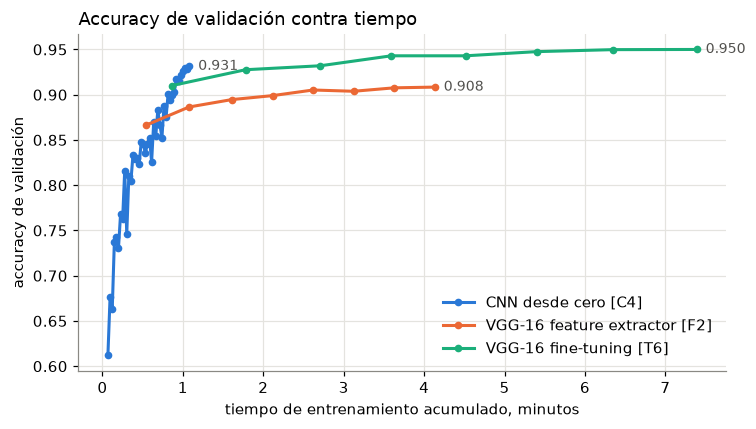

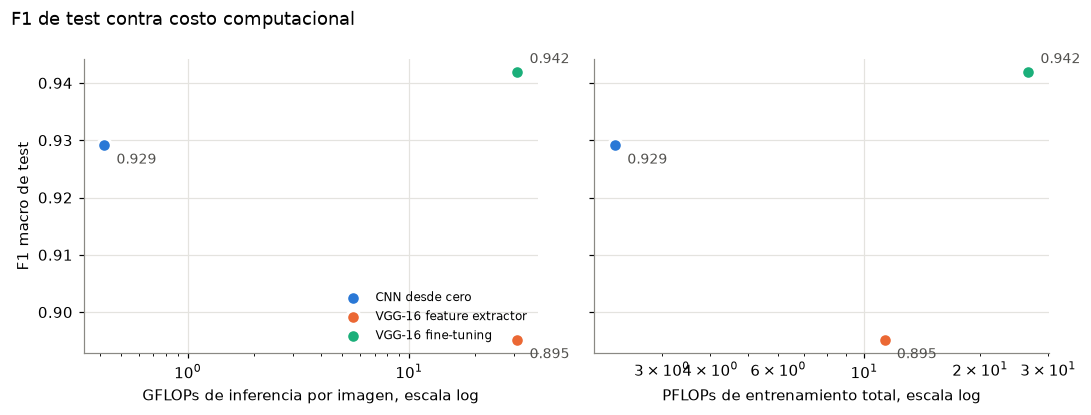

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
for fam in ["cnn", "fe", "ft"]:
    reg = next(r for r in REGISTROS if r["nombre"] == MEJOR_POR_FAMILIA[fam])
    t_acum = np.cumsum(reg["hist"]["t_epoch"]) / 60
    ax.plot(t_acum, reg["hist"]["val_acc"], color=COLOR_MODELO[fam], marker="o", ms=4,
            label=f"{NOMBRE_FAMILIA[fam]} [{reg['nombre']}]")
    ax.annotate(f"{max(reg['hist']['val_acc']):.3f}", (t_acum[-1], reg["hist"]["val_acc"][-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color="#52514e")
ax.set_xlabel("tiempo de entrenamiento acumulado, minutos")
ax.set_ylabel("accuracy de validación")
ax.set_title("Accuracy de validación contra tiempo", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.savefig("figuras/acc_vs_tiempo.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, clave, etiqueta, escala in [(axes[0], "flops_inf", "GFLOPs de inferencia por imagen", 1e9),
                                    (axes[1], "flops_train_total", "PFLOPs de entrenamiento total", 1e15)]:
    for fam in ["cnn", "fe", "ft"]:
        xv, yv = COSTOS[fam][clave] / escala, RES_TEST[fam]["f1"]
        ax.scatter(xv, yv, s=80, color=COLOR_MODELO[fam], edgecolor="white", linewidth=2, zorder=3, label=NOMBRE_FAMILIA[fam])
        ax.annotate(f"{yv:.3f}", (xv, yv), xytext=(8, 6 if fam == "ft" else -12), textcoords="offset points",
                    fontsize=9, color="#52514e")
    ax.set_xscale("log"); ax.set_xlabel(etiqueta + ", escala log")
axes[0].set_ylabel("F1 macro de test")
axes[0].legend(frameon=False, loc="lower right", fontsize=8)
fig.suptitle("F1 de test contra costo computacional", x=0.01, ha="left")
plt.tight_layout(); plt.savefig("figuras/f1_vs_flops.png"); plt.show()

In [32]:
resumen = {
    "hardware": HARDWARE, "mejor": MEJOR_POR_FAMILIA,
    "test": {f: {k: v for k, v in RES_TEST[f].items() if k not in ("y_true", "y_pred")} for f in RES_TEST},
    "test_10": {f: {k: v for k, v in RES_10[f]["test"].items() if k not in ("y_true", "y_pred")} for f in RES_10},
    "reg_10": {f: {k: RES_10[f]["reg"][k] for k in ["mejor_epoch", "t_epoch", "t_total", "mem_pico_mb", "val"]} for f in RES_10},
    "costos": COSTOS, "pares": PARES,
    "matrices": {f: confusion_matrix(RES_TEST[f]["y_true"], RES_TEST[f]["y_pred"]).tolist() for f in RES_TEST},
    "stats": {"media_cifar": media_cifar_full.tolist(), "desv_cifar": desv_cifar_full.tolist()},
}
with open("resultados/resumen.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=1, default=float)
guardar_registros()
print("Hardware utilizado:", HARDWARE["gpu"], "|", HARDWARE["cpu"])

Hardware utilizado: NVIDIA GeForce RTX 5070 Ti | AMD Ryzen 7 7800X3D 8-Core Processor


La CNN desde cero usa 26 veces menos parámetros y 74 veces menos FLOPs de inferencia que VGG-16, y su entrenamiento completo requiere 2.3 PFLOPs frente a 11.3 del feature extractor y 26.6 del fine-tuning. La latencia con lote de 1 solo difiere 1.6 veces, 0.79 ms frente a 1.28 ms, porque con una sola imagen la GPU está subutilizada y domina el costo fijo de lanzar kernels; con lote de 256 la diferencia de throughput es de 66 veces, 96,600 frente a 1,470 imágenes por segundo, muy cerca de la relación de FLOPs. En la gráfica de accuracy contra tiempo la CNN alcanza 93 % en poco más de un minuto, mientras que el fine-tuning necesita más de 7 minutos para llegar a 95 %, y el feature extractor se estanca cerca de 91 %; la CNN lo supera antes del primer minuto.

Hardware utilizado: GPU NVIDIA GeForce RTX 5070 Ti de 16 GB, CPU AMD Ryzen 7 7800X3D, Windows 11, PyTorch 2.14 con CUDA 13.0.

## 6. Discusión y análisis

### Mejor desempeño en test y su costo

VGG-16 con fine-tuning obtuvo el mejor desempeño en test, 94.2 % de accuracy y 0.942 de F1, frente a 92.9 % de la CNN desde cero y 89.5 % del feature extractor. La diferencia con la CNN es de 1.3 puntos, lo que equivale a reducir los errores de 7.1 % a 5.8 %, unos 18 % menos errores. Para lograrlo usa 26 veces más parámetros, 74 veces más FLOPs por imagen en inferencia, 12 veces más cómputo de entrenamiento y casi 7 veces más tiempo. Si el objetivo es la máxima accuracy y el hardware no es una restricción, la mejora sí se justifica; en la mayoría de los escenarios prácticos, un costo tan alto para 1.3 puntos no se justifica. El feature extractor no justifica su costo en ningún caso con el dataset completo, porque consume más que la CNN y rinde menos.

### Mejor relación entre desempeño y recursos

La CNN desde cero ofrece la mejor relación. En la gráfica de F1 contra FLOPs ocupa la esquina superior izquierda: con 0.42 GFLOPs por imagen y 2.3 PFLOPs de entrenamiento queda a solo 1.3 puntos del mejor modelo, que necesita 30.9 GFLOPs por imagen y 26.6 PFLOPs. El feature extractor queda dominado, con más costo y menor F1 que la CNN. En la gráfica de accuracy contra tiempo, la CNN supera el 90 % de validación a los 48 segundos, mientras que el feature extractor necesita 4 minutos para llegar a 90.8 %.

### Utilidad de las features preentrenadas a 32x32

Las features preentrenadas siguen siendo útiles porque los primeros bloques de VGG-16 detectan bordes, colores, texturas y partes de objetos, patrones genéricos que también aparecen en CIFAR-10, y porque las clases de CIFAR-10 tienen equivalentes cercanos en ImageNet. Al redimensionar a 224x224 el objeto ocupa una escala parecida a la de las fotografías de ImageNet, de modo que los campos receptivos de cada bloque ven estructuras del tamaño esperado. El problema es que la imagen ampliada no contiene detalle nuevo, solo interpolación, y los bloques superiores, especializados en detalles finos de ImageNet, no encajan bien; por eso el feature extractor rinde menos que la CNN y el fine-tuning, que adapta esos bloques, rinde más. En costo, el redimensionamiento multiplica los píxeles por 49 y con ello los FLOPs y la memoria de activaciones; la iteración F4 muestra que a 128x128 se pierde menos de un punto de accuracy con la mitad del tiempo por epoch.

### Bloques descongelados y learning rate del backbone

Descongelar más bloques mejoró el resultado de forma consistente: 92.6 % con el bloque 5, 93.8 % con los bloques 4 y 5 y 94.6 % con los bloques 3 a 5, a cambio de más tiempo por epoch. Un learning rate de backbone muy bajo, 0.0001, desperdicia esa capacidad y deja el modelo en 92.0 %. Uno igual al del clasificador, 0.01, sube la accuracy pero produce la mayor brecha entre pérdida de entrenamiento y de validación, que es la señal de overfitting más clara del fine-tuning. No se observaron señales de catastrophic forgetting: la accuracy de la primera epoch siempre superó a la del feature extractor y la pérdida de validación no tuvo un aumento sostenido. El mejor equilibrio fue un learning rate intermedio de 0.003 sobre los bloques 3 a 5.

### Efecto de la cantidad de datos

La CNN desde cero fue la más afectada: con el 10 % de los datos perdió 20.4 puntos de F1, frente a 5.5 y 5.7 de los modelos preentrenados. Esto coincide con lo visto en clase. Con pocos datos y un dominio similar al de preentrenamiento conviene feature extraction, porque solo se entrena la cabeza y el riesgo de sobreajuste es bajo. Con una cantidad media de datos conviene fine-tuning de los bloques superiores, que aquí fue la mejor opción en ambos escenarios. Entrenar desde cero solo compite cuando hay suficientes datos para aprender las features, como ocurrió con las 45,000 imágenes, o cuando el dominio es muy distinto al de preentrenamiento.

### Matrices de confusión

Los tres modelos comparten el par más difícil, cat y dog, y la confusión entre automobile y truck, tal como se anticipó en la exploración. Sin embargo, no cometen los mismos errores en la misma proporción: el feature extractor duplica los errores entre vehículos y confunde más animales como bird, deer y horse; la CNN destaca en cat con frog y airplane con ship; y el fine-tuning reduce la mayoría de las confusiones sin eliminar la de cat y dog, aunque confunde más dog con horse que la CNN.

### Despliegue

En un servidor con GPU se elegiría VGG-16 con fine-tuning, porque ofrece la mejor accuracy y su latencia de 1.3 ms por imagen y su throughput de casi 1,500 imágenes por segundo son suficientes para un servicio en línea. En un dispositivo móvil se elegiría la CNN desde cero: pesa unos 21 MB en float32 y menos de 6 MB cuantizada a int8, requiere 0.42 GFLOPs por imagen y pierde solo 1.3 puntos, mientras que VGG-16 ocupa más de 500 MB y exige 74 veces más cómputo. Como alternativa preentrenada para el móvil se considerarían MobileNetV3 o EfficientNet-B0, que usan convoluciones separables en profundidad, tienen alrededor de 5 millones de parámetros y menos de 0.4 GMACs a 224x224, y permitirían combinar los beneficios del transfer learning con un costo compatible con un teléfono.